<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data">Breast Cancer Wisconsin (Diagnostic)</a></div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer_logo.png" width="96"></th>
 </tr>
</table>

<div style='text-align: center'>
<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer.png" width="512">
</div>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'>Les variables sont calculées à partir d'une image numérisée d'une ponction d'aspiration à l'aiguille fine (FNA) utilisée pour obtenir des échantillons à partir de ganglions lymphatique. Elles décrivent les caractéristiques des noyaux cellulaires présents sur l'image.</div>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic">Veuillez vous référer à la page <span style="font-weight: bold; color: blue">UC Irvine Machine Learning Repository</span>
 officielle pour plus de détails.</a></div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>
## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries </div></b>

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

In [2]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans


from matplotlib.colors import ListedColormap
from itertools import cycle
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler,MinMaxScaler,label_binarize
from sklearn.feature_extraction import DictVectorizer
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeCV
from sklearn.svm import NuSVC, SVC, OneClassSVM
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct, Matern, WhiteKernel

from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from lightgbm import LGBMClassifier
from xgboost  import XGBClassifier

from sklearn.metrics import make_scorer, confusion_matrix, roc_curve, auc, accuracy_score, log_loss, hamming_loss, \
                            precision_score, recall_score, f1_score, fbeta_score, jaccard_score, \
                            precision_recall_curve, average_precision_score, balanced_accuracy_score, \
                            classification_report, silhouette_score
from sklearn.metrics import roc_auc_score, zero_one_loss
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, RepeatedKFold, \
                                    RepeatedStratifiedKFold, LeavePOut, LeaveOneGroupOut, \
                                    LeavePGroupsOut, ShuffleSplit, StratifiedShuffleSplit, TimeSeriesSplit, GridSearchCV

from sklearn.multiclass import OneVsRestClassifier,OneVsOneClassifier

from sklearn.neighbors  import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble   import IsolationForest
from sklearn.svm        import OneClassSVM

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))
from prjFormation import palette

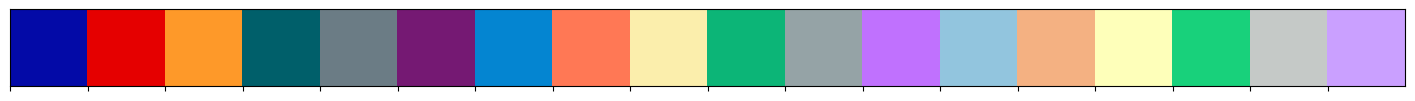

In [4]:
# palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
#             "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
#             "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
#           ]
sns.palplot(sns.color_palette(palette[:18]))

In [5]:
from classificationBinaires import initDictionnaireClassificateurs, executionEssaiComparaisonClassificateurs,\
                                   affichageEvolutionMetriques, affichageROC, executeValidationCroisee

In [6]:
from prjFormation import initProjet,affichageDonnees2d,affichageDonnees3d,createLinkageMatrix, afficheDendrogram,\
                         affichageDistribution,afficheColonneCible, add_median_labels, formatPct

In [7]:
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

In [8]:
projet = initProjet(repertoireRacine='.',nomProjet='BreastCancerWisconsin')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>
<table>
        <tr>                                                                                   
             <th style='padding:15px;color:#030aa7;font-size:150%;text-align: left;font-weight: bold;font-family: Georgia, serif'>data.csv</th>
             <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/breast_cancer_logo.png" width="128"></th>
        </tr>  
<table>   
<table>
        <tr>                                                                                   
             <th  style="text-align:left;background-color:#053061;color:white;"> </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Colonne initiale </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Description</th>
        </tr>    
    <tr>
        <th  style="text-align:left"> </th>                            
        <th  style="text-align:left;font-style: italic">ID number</th> 
        <th  style="text-align:left;font-style: italic">index</th>
    </tr>    
    <tr>
        <th  style="text-align:left">0 </th>                            
        <th  style="text-align:left;color:red;font-style: italic">Diagnosis</th> 
        <th  style="text-align:left;color:red;font-style: italic">M = malignant, B = benign</th>
    </tr>    
    <tr>
        <th  style="text-align:left">1 </th>                            
        <th  style="text-align:left">radius </th>                            
        <th  style="text-align:left"></th>
    </tr>    
    <tr>
        <th  style="text-align:left">2 </th>                            
        <th  style="text-align:left">texture </th>                          
        <th  style="text-align:left">standard deviation of gray-scale values</th>
    </tr>    
    <tr>
        <th  style="text-align:left">3 </th>                            
        <th  style="text-align:left">perimeter </th>                         
        <th  style="text-align:left"></th>
    </tr>    
    <tr>
        <th  style="text-align:left">4 </th>                            
        <th  style="text-align:left">area</th>                               
        <th  style="text-align:left"></th>
    </tr> 
    <tr>
        <th  style="text-align:left">5 </th>                            
        <th  style="text-align:left">smoothness </th>                            
        <th  style="text-align:left">local variation in radius lengths</th>
    </tr>  
    <tr>
        <th  style="text-align:left">6 </th>                            
        <th  style="text-align:left">compactness </th>                      
        <th  style="text-align:left">$\frac{perimeter^2}{area - 1.0}$</th>
    </tr>    
    <tr>
        <th  style="text-align:left">7 </th>                            
        <th  style="text-align:left">concavity </th>              
        <th  style="text-align:left">severity of concave portions of the contour</th>
    </tr>  
    <tr>
        <th  style="text-align:left">8 </th>                            
        <th  style="text-align:left">concave points </th>                            
        <th  style="text-align:left">number of concave portions of the contour</th>
    </tr>   
    <tr>
        <th  style="text-align:left">9 </th>                            
        <th  style="text-align:left">symmetry </th>                           
        <th  style="text-align:left"></th>
    </tr> 
    <tr>
        <th  style="text-align:left">10 </th>                            
        <th  style="text-align:left">fractal dimension </th>                 
        <th  style="text-align:left">"coastline approximation" - 1</th>
    </tr>    
</table>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'>La moyenne, l’écart type et la « pire valeur » ou la plus grande (moyenne des trois valeurs les plus grandes) de ces variables ont été calculées pour chaque image, ce qui a donné lieu à 30 variables.</div>

In [9]:
donnees = pd.read_csv('../donnees/data.csv', index_col='id').drop(columns='Unnamed: 32')
donnees.sort_index(axis=1, inplace=True)
dictDiagnosis,dictRDiagnosis,dictLabels = {'M':1,'B':0},{1:'M',0:'B'},{1:'malignant',0:'benign'}

cible = 'diagnosis'

In [10]:
donnees.sample(5)

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
id,,,,,,,,,,,,,,,,,,,,,
9113514,286.3,20.98,380.2,0.05428,0.012570,0.12550,0.005769,0.003934,0.02500,0.01479,...,11.15,0.08311,0.010980,0.1388,0.1680,0.02693,0.3057,18.10,1.3120,24.62
907367,307.3,11.60,376.3,0.03912,0.005697,0.07094,0.005159,0.003527,0.02579,0.00247,...,11.11,0.08117,0.005724,0.1126,0.1630,0.01445,0.2349,21.28,1.3410,28.94
908445,1110.0,103.90,1603.0,0.13890,0.040880,0.34630,0.087440,0.018340,0.17080,0.15940,...,22.66,0.10180,0.008074,0.1390,0.1943,0.02383,0.3007,21.97,1.9310,30.93
8711561,419.8,38.34,543.9,0.11410,0.024050,0.18920,0.037380,0.011520,0.07909,0.06843,...,13.32,0.10890,0.009433,0.1358,0.1993,0.03397,0.3168,20.18,1.6930,26.21
86561,588.7,17.91,725.9,0.06136,0.009169,0.13500,0.011410,0.004814,0.05104,0.01420,...,15.49,0.08785,0.004599,0.1157,0.1614,0.01247,0.2364,17.21,0.8561,23.58


>> <div style='padding:15px;color:#030aa7;background-color:#d8dcd6;font-size:120%;text-align: left;font-family: Georgia, serif'>Il n'y a pas de valeurs non renseignées</div>

In [11]:
donnees.isna().sum().sum()

np.int64(0)

In [12]:
donnees.describe().style.format("{:0.2f}") 

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,concavity_se,concavity_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,654.89,40.34,880.58,0.10,0.03,0.25,0.05,0.01,0.11,0.09,0.03,0.27,0.06,0.00,0.08,91.97,2.87,107.26,14.13,0.41,16.27,0.10,0.01,0.13,0.18,0.02,0.29,19.29,1.22,25.68
std,351.91,45.49,569.36,0.05,0.02,0.16,0.04,0.01,0.07,0.08,0.03,0.21,0.01,0.00,0.02,24.30,2.02,33.60,3.52,0.28,4.83,0.01,0.00,0.02,0.03,0.01,0.06,4.30,0.55,6.15
min,143.50,6.80,185.20,0.02,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.06,43.79,0.76,50.41,6.98,0.11,7.93,0.05,0.00,0.07,0.11,0.01,0.16,9.71,0.36,12.02
25%,420.30,17.85,515.30,0.06,0.01,0.15,0.02,0.01,0.06,0.03,0.02,0.11,0.06,0.00,0.07,75.17,1.61,84.11,11.70,0.23,13.01,0.09,0.01,0.12,0.16,0.02,0.25,16.17,0.83,21.08
50%,551.10,24.53,686.50,0.09,0.02,0.21,0.03,0.01,0.10,0.06,0.03,0.23,0.06,0.00,0.08,86.24,2.29,97.66,13.37,0.32,14.97,0.10,0.01,0.13,0.18,0.02,0.28,18.84,1.11,25.41
75%,782.70,45.19,1084.00,0.13,0.03,0.34,0.07,0.01,0.16,0.13,0.04,0.38,0.07,0.00,0.09,104.10,3.36,125.40,15.78,0.48,18.79,0.11,0.01,0.15,0.20,0.02,0.32,21.80,1.47,29.72
max,2501.00,542.20,4254.00,0.35,0.14,1.06,0.20,0.05,0.29,0.43,0.40,1.25,0.10,0.03,0.21,188.50,21.98,251.20,28.11,2.87,36.04,0.16,0.03,0.22,0.30,0.08,0.66,39.28,4.88,49.54


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

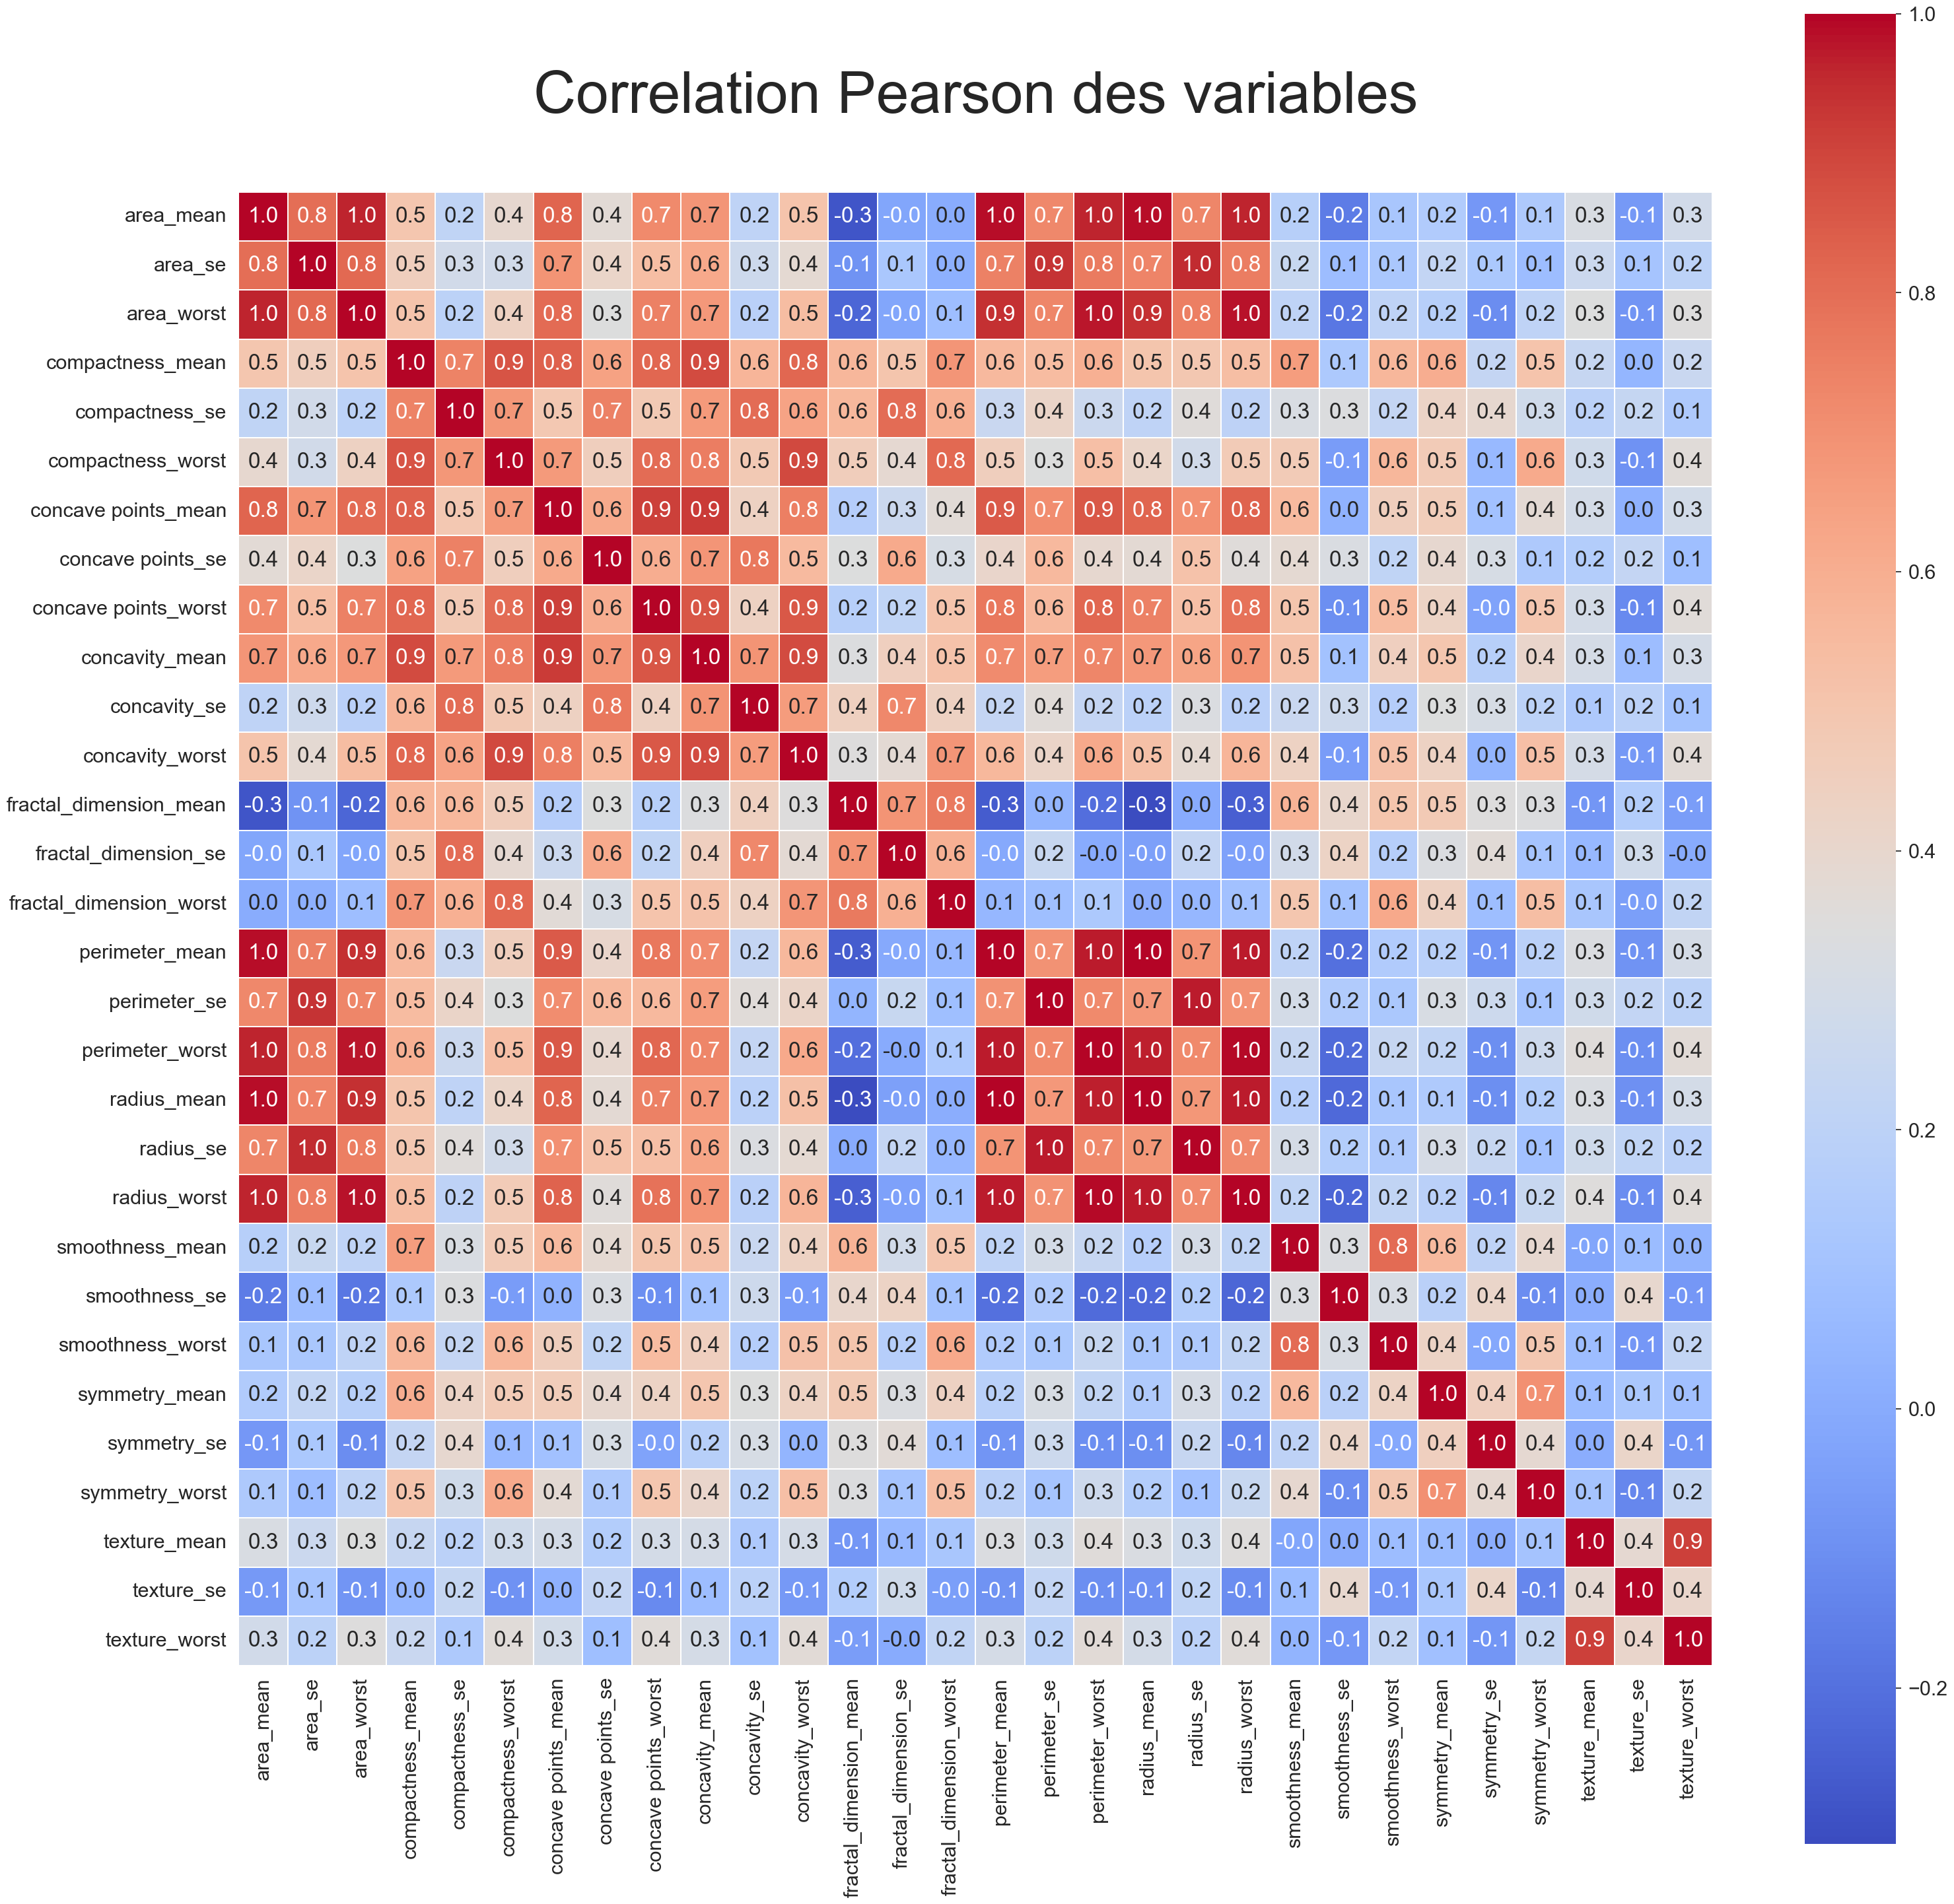

In [13]:
plt.figure(figsize=(36,36))
plt.title('Correlation Pearson des variables', y=1.05, size=64)
sns.heatmap(donnees.drop(columns=cible).corr(), fmt= '.1f',linewidths=0.3,vmax=1.0, 
            square=True, cmap='coolwarm', linecolor='white', annot=True);

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonApprentissageTest.png" width="800">

In [14]:
X = donnees.drop(columns=cible)
y = donnees[cible].apply(lambda x: dictDiagnosis[x])

X_train, X_test, y_train, y_test = train_test_split( X, 
                                                     y, 
                                                     test_size=0.2, 
                                                     random_state=0, 
                                                     stratify = y
                                                   ) 
donnees.loc[X_train.index,'échantillon'] = 'apprentissage'
donnees.loc[X_test.index ,'échantillon'] = 'test'
donnees.to_parquet(os.path.join(projet.repertoireDonnees,'donnees_echantillons.parquet'))

In [15]:
donnees = pd.read_parquet(os.path.join(projet.repertoireDonnees,'donnees_echantillons.parquet'))
X_train, X_test = \
                  donnees.loc[donnees['échantillon']=='apprentissage',donnees.drop(columns=[cible,'échantillon']).columns],\
                  donnees.loc[donnees['échantillon']=='test',donnees.drop(columns=[cible,'échantillon']).columns]

y_train, y_test = \
                  donnees.loc[donnees['échantillon']=='apprentissage',cible].apply(lambda x: dictDiagnosis[x]),\
                  donnees.loc[donnees['échantillon']=='test',cible].apply(lambda x: dictDiagnosis[x])

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

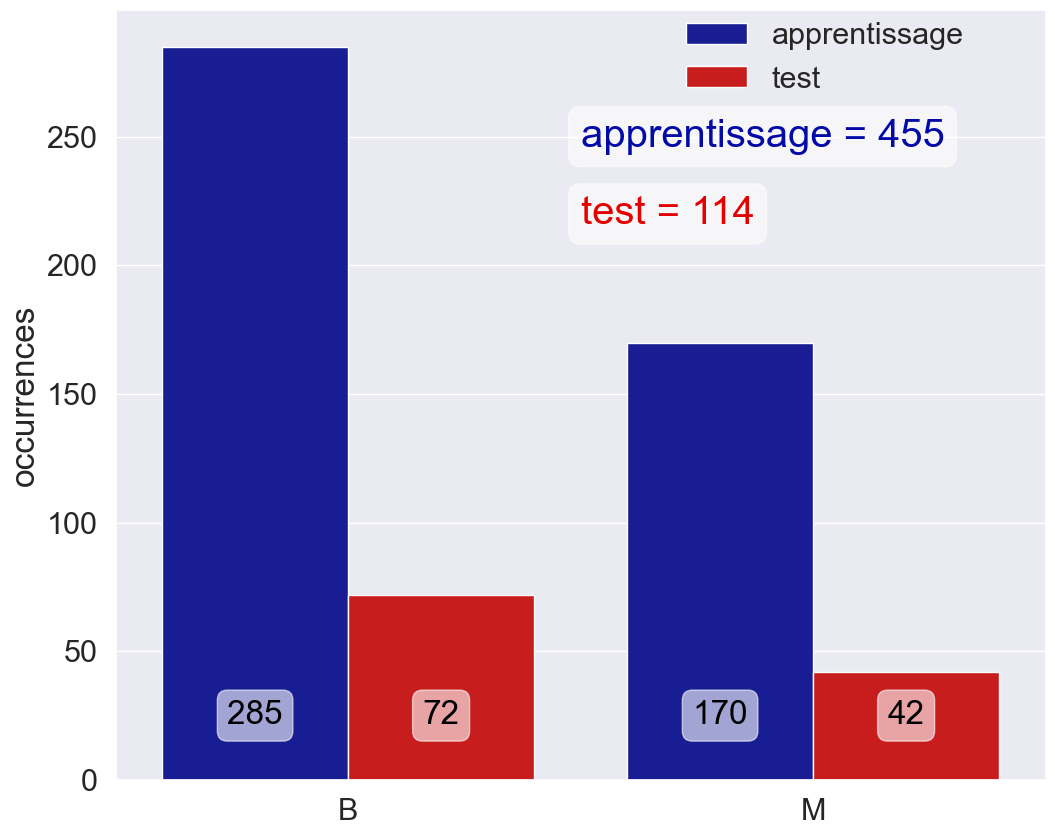

In [16]:
plt.figure(figsize=(12,10))
graph = sns.countplot(x=cible,
                      hue='échantillon',
                      data=donnees.sort_values([cible,'échantillon']), 
                      palette=palette
                     );

for i,nb in enumerate(donnees.groupby([cible,'échantillon'])[cible].count()):
    if i%2 == 0 : val = i/2
    delta =  val - 0.2 +(i%2)*0.4
    graph.text(
                delta ,
                25,
                nb,
                color='black',
#                 rotation='vertical',
#                 size='large',
#                 fontsize='large',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
affichage = donnees.groupby('échantillon').agg({'diagnosis':'count'})
graph.text(
                0.5 ,
                250,
                f"apprentissage = {affichage.loc['apprentissage','diagnosis']}",
                color="#030aa7",
                fontsize='large',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='left',
               )
graph.text(
                0.5 ,
                220,
                f"test = {affichage.loc['test','diagnosis']}",
                color="#e50000",
                fontsize='large',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='left',
               )

graph.set_ylabel('occurrences');
graph.set_xlabel('');
graph.legend(bbox_to_anchor=(.6, 1), loc='upper left', borderaxespad=0);

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Déclaration des classificateurs </div></b>

In [17]:
classificateursDict =  initDictionnaireClassificateurs(arbres=12)
classificateursDict.pop('LightGBM'),\
classificateursDict.pop('XGBoost'),\
classificateursDict.pop('Stochastic_GD')

(LGBMClassifier(min_child_samples=10, min_split_gain=0.01, n_estimators=12,
                num_leaves=20, reg_alpha=0.1, reg_lambda=20),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=12,
               n_jobs=None, num_parallel_tree=None, ...),
 SGDClassifier(alpha=0.01, loss='log_loss', max_iter=200))

In [18]:
classificateursDict

{'Random_Forest': RandomForestClassifier(max_depth=6, max_features=3, min_samples_split=4,
                        n_estimators=12, n_jobs=-1),
 'AdaBoost': AdaBoostClassifier(n_estimators=12),
 'LogisticRegression': LogisticRegression(C=0.81113, max_iter=3000, n_jobs=-1),
 'Gaussian_Process': GaussianProcessClassifier(n_jobs=-1),
 'Nearest_Neighbors': KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1, n_neighbors=17, p=1,
                      weights='distance'),
 'Linear_SVM': SVC(C=10, kernel='linear', probability=True),
 'Radial_NuSVM': NuSVC(gamma=0.5, nu=0.195, probability=True),
 'Poly_NuSVM': NuSVC(kernel='poly', nu=0.1, probability=True),
 'GaussianNaiveBayes': GaussianNB(),
 'QuadraticDiscriminant': QuadraticDiscriminantAnalysis(),
 'Neural_Net': MLPClassifier(alpha=1)}

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Essai initial avec les donnes sans aucun traitement</div></b> 